### Rent chatGPT forsøk på å lage analyse for 2023 basert på min analyse fra 2024

In [6]:
# ============================================================================
# TASK 2.6 ANALYSIS - 2023 DATA (ALU 23)
# ============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from typing import Dict, List, Tuple, Optional, Union
import warnings
from scipy.stats import entropy
import logging

# Configure logging for better debugging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore', category=FutureWarning)

# Set style for consistent plotting
plt.style.use('default')
sns.set_palette("husl")

In [7]:
# ============================================================================
# TASK 2.6 DATA PROCESSOR CLASS - 2023 VERSION 
# ============================================================================

class Task26DataProcessor2023:
    """
    Data processor for Task 2.6 - 2023 (ALU 23) with different response format.
    This task appears to have different response types compared to 2024.
    """
    
    def __init__(self):
        pass
        
    def load_and_validate_data(self, file_path: str = "../data/cleaned_data/IN1020_2023_cleaned_data.csv") -> pd.DataFrame:
        """Load and validate exam data with enhanced error handling."""
        try:
            df = pd.read_csv(file_path)
            logger.info(f"Loaded data: {len(df)} rows, {len(df.columns)} columns")
            
            # Check unique question numbers for debugging
            unique_questions = sorted(df['question_number'].unique())
            logger.info(f"Unique question numbers: {unique_questions}")
            
            # Validate required columns
            required_columns = ['student_id', 'question_number', 'candidate_response_code', 'gender']
            missing_cols = [col for col in required_columns if col not in df.columns]
            if missing_cols:
                logger.warning(f"Missing columns: {missing_cols}")
            
            return df
        except Exception as e:
            logger.error(f"Error loading data: {e}")
            raise

    def get_task_data(self, df: pd.DataFrame, question_number: Union[str, float] = 2.6) -> pd.DataFrame:
        """Get task-specific data with validation."""
        task_data = df[df['question_number'] == question_number].copy()
        logger.info(f"Retrieved {len(task_data)} responses for Task {question_number}")
        
        # Inspect the unique response codes for this task
        unique_responses = task_data['candidate_response_code'].value_counts()
        logger.info(f"Unique response codes for Task {question_number}:")
        for response, count in unique_responses.head(20).items():
            logger.info(f"  {response}: {count}")
            
        return task_data

    def calculate_grade_thresholds(self, max_score: float) -> Dict[str, float]:
        """Calculate adjusted grade thresholds based on max score."""
        original_thresholds = {'A': 92, 'B': 77, 'C': 58, 'D': 46, 'E': 40, 'F': 0}
        return {grade: round((original / 100) * max_score, 2) 
                for grade, original in original_thresholds.items()}

    def assign_grade(self, score: float, thresholds: Dict[str, float]) -> str:
        """Assign grade based on score and thresholds."""
        if pd.isna(score):
            return 'F'
        for grade in ['A', 'B', 'C', 'D', 'E']:
            if score >= thresholds[grade]:
                return grade
        return 'F'

    def assign_quartile(self, score: float, q1: float, q2: float, q3: float) -> str:
        """Assign quartile based on score."""
        if pd.isna(score):
            return 'Q1'
        if score >= q3:
            return 'Q4'
        elif score >= q2:
            return 'Q3'
        elif score >= q1:
            return 'Q2'
        return 'Q1'

# Initialize the processor
processor = Task26DataProcessor2023()

# Load and validate data
df = processor.load_and_validate_data()

# Calculate max score and grade thresholds
max_score = df['auto_total_score'].max()
grade_thresholds = processor.calculate_grade_thresholds(max_score)

logger.info(f"Max score: {max_score}")
logger.info(f"Grade thresholds: {grade_thresholds}")

# Get Task 2.6 data and inspect the response format
task_data = processor.get_task_data(df, 2.6)

2025-10-23 12:42:06,770 - INFO - Loaded data: 64809 rows, 13 columns
2025-10-23 12:42:06,772 - INFO - Unique question numbers: [np.float64(1.1), np.float64(1.2), np.float64(1.3), np.float64(1.4), np.float64(1.5), np.float64(1.6), np.float64(1.7), np.float64(1.8), np.float64(1.9), np.float64(2.1), np.float64(2.2), np.float64(2.3), np.float64(2.4), np.float64(2.5), np.float64(2.6), np.float64(3.1), np.float64(3.2), np.float64(3.3), np.float64(3.4), np.float64(3.5), np.float64(3.6), np.float64(3.7), np.float64(4.1), np.float64(4.2), np.float64(4.3), np.float64(4.4), np.float64(4.5), np.float64(4.6), np.float64(4.7), np.float64(4.8), np.float64(4.9)]
2025-10-23 12:42:06,774 - INFO - Max score: 95.5
2025-10-23 12:42:06,775 - INFO - Grade thresholds: {'A': 87.86, 'B': 73.53, 'C': 55.39, 'D': 43.93, 'E': 38.2, 'F': 0.0}
2025-10-23 12:42:06,778 - INFO - Retrieved 3540 responses for Task 2.6
2025-10-23 12:42:06,780 - INFO - Unique response codes for Task 2.6:
2025-10-23 12:42:06,780 - INFO -   

In [8]:
# ============================================================================
# DATA ANALYSIS AND RESPONSE PROCESSING - 2023 TASK 2.6
# ============================================================================

class Task26DataAnalyzer2023:
    """
    Analyzer for Task 2.6 - 2023 (ALU 23) data.
    """
    
    def __init__(self, processor: Task26DataProcessor2023):
        self.processor = processor
        self.task_data = None
        
    def analyze_response_patterns(self, task_data: pd.DataFrame) -> pd.DataFrame:
        """Analyze the response patterns in the 2023 Task 2.6 data."""
        logger.info("Analyzing response patterns for Task 2.6 - 2023...")
        
        # Get basic statistics
        total_responses = len(task_data)
        unique_students = task_data['student_id'].nunique()
        
        logger.info(f"Total responses: {total_responses}")
        logger.info(f"Unique students: {unique_students}")
        logger.info(f"Average responses per student: {total_responses / unique_students:.1f}")
        
        # Analyze response codes
        response_counts = task_data['candidate_response_code'].value_counts()
        logger.info(f"Total unique response codes: {len(response_counts)}")
        
        # Clean response codes and analyze
        task_data_clean = task_data.copy()
        task_data_clean['response_clean'] = task_data_clean['candidate_response_code'].apply(
            lambda x: str(x).strip() if pd.notna(x) else 'No Response'
        )
        
        # Get top 15 responses overall
        top_responses = task_data_clean['response_clean'].value_counts().head(15)
        
        return task_data_clean, top_responses
    
    def analyze_by_gender(self, task_data_clean: pd.DataFrame, top_responses: pd.Series) -> Dict:
        """Analyze response patterns by gender."""
        logger.info("Analyzing response patterns by gender...")
        
        gender_analysis = {}
        
        for gender in ['F', 'M']:
            gender_data = task_data_clean[task_data_clean['gender'] == gender]
            total_gender_responses = len(gender_data)
            unique_gender_students = gender_data['student_id'].nunique()
            
            # Get response counts for this gender
            gender_response_counts = gender_data['response_clean'].value_counts()
            
            # Calculate percentages for top responses
            gender_percentages = {}
            for response in top_responses.index:
                count = gender_response_counts.get(response, 0)
                percentage = (count / total_gender_responses) * 100 if total_gender_responses > 0 else 0
                gender_percentages[response] = {
                    'count': count,
                    'percentage': percentage
                }
            
            gender_analysis[gender] = {
                'total_responses': total_gender_responses,
                'unique_students': unique_gender_students,
                'response_percentages': gender_percentages,
                'response_counts': gender_response_counts
            }
            
            logger.info(f"Gender {gender}: {total_gender_responses} responses from {unique_gender_students} students")
        
        return gender_analysis
    
    def get_student_performance_data(self, df: pd.DataFrame) -> pd.DataFrame:
        """Get student performance data for grade/quartile analysis."""
        student_data = df[['student_id', 'gender', 'auto_total_score']].drop_duplicates()
        
        # Assign grades
        grade_thresholds = self.processor.calculate_grade_thresholds(df['auto_total_score'].max())
        student_data['grade'] = student_data['auto_total_score'].apply(
            lambda x: self.processor.assign_grade(x, grade_thresholds)
        )
        
        # Assign quartiles
        q1, q2, q3 = student_data['auto_total_score'].quantile([0.25, 0.5, 0.75])
        student_data['quartile'] = student_data['auto_total_score'].apply(
            lambda x: self.processor.assign_quartile(x, q1, q2, q3)
        )
        
        return student_data

# Initialize analyzer
analyzer = Task26DataAnalyzer2023(processor)

# Analyze response patterns
task_data_clean, top_responses = analyzer.analyze_response_patterns(task_data)

print("\\n" + "="*60)
print("TOP 15 RESPONSE PATTERNS - TASK 2.6 (ALU 23) - 2023")
print("="*60)
for i, (response, count) in enumerate(top_responses.items(), 1):
    percentage = (count / len(task_data_clean)) * 100
    print(f"{i:2d}. {response}: {count} responses ({percentage:.1f}%)")
print("="*60)

2025-10-23 12:42:06,805 - INFO - Analyzing response patterns for Task 2.6 - 2023...
2025-10-23 12:42:06,806 - INFO - Total responses: 3540
2025-10-23 12:42:06,807 - INFO - Unique students: 590
2025-10-23 12:42:06,808 - INFO - Average responses per student: 6.0
2025-10-23 12:42:06,809 - INFO - Total unique response codes: 61


\n============================================================
TOP 15 RESPONSE PATTERNS - TASK 2.6 (ALU 23) - 2023
 1. 0: 1028 responses (29.0%)
 2. 5: 279 responses (7.9%)
 3. No Response: 273 responses (7.7%)
 4. 20: 255 responses (7.2%)
 5. 10: 223 responses (6.3%)
 6. 3: 176 responses (5.0%)
 7. 50: 169 responses (4.8%)
 8. 25: 113 responses (3.2%)
 9. 2: 108 responses (3.1%)
10. 1: 105 responses (3.0%)
11. 30: 101 responses (2.9%)
12. 4: 91 responses (2.6%)
13. 15: 82 responses (2.3%)
14. 40: 74 responses (2.1%)
15. 100: 69 responses (1.9%)


In [9]:
# ============================================================================
# VISUALIZATION CLASS - 2023 TASK 2.6 ANALYSIS
# ============================================================================

class Task26Visualizer2023:
    """
    Visualizer for Task 2.6 - 2023 (ALU 23) analysis with gender comparison.
    """
    
    def __init__(self, processor: Task26DataProcessor2023, analyzer: Task26DataAnalyzer2023):
        self.processor = processor
        self.analyzer = analyzer
        
    def create_base_plot(self, figsize=(12, 8), title="", xlabel="", ylabel=""):
        """Create base plot with consistent styling."""
        fig, ax = plt.subplots(figsize=figsize)
        ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
        ax.set_xlabel(xlabel, fontsize=12, fontweight='bold')
        ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--')
        return fig, ax
    
    def plot_gender_response_comparison(self, gender_analysis: Dict, top_responses: pd.Series, top_n=15):
        """Create side-by-side bar charts comparing response patterns by gender."""
        
        # Create subplots for each gender
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 12))
        
        genders = ['F', 'M']
        axes = [ax1, ax2]
        gender_names = {'F': 'Female', 'M': 'Male'}
        light_blue = 'lightblue'
        
        # Get top responses to ensure consistency
        top_response_list = top_responses.head(top_n).index.tolist()
        
        for i, (gender, ax) in enumerate(zip(genders, axes)):
            gender_data = gender_analysis[gender]
            total_responses = gender_data['total_responses']
            unique_students = gender_data['unique_students']
            
            if total_responses == 0:
                ax.text(0.5, 0.5, f'No data available for {gender_names[gender]}', 
                       ha='center', va='center', transform=ax.transAxes, fontsize=14)
                ax.set_title(f'{gender_names[gender]} Students\\n(0 responses)', 
                            fontsize=14, fontweight='bold')
                continue
            
            # Get percentages for top responses
            percentages = []
            counts = []
            for response in top_response_list:
                response_data = gender_data['response_percentages'].get(response, {'percentage': 0, 'count': 0})
                percentages.append(response_data['percentage'])
                counts.append(response_data['count'])
            
            # Create bars
            bars = ax.bar(range(len(top_response_list)), percentages, 
                         color=light_blue, alpha=0.8, edgecolor='black', linewidth=0.5)
            
            # Customize axes
            ax.set_title(f'{gender_names[gender]} Students\\n({total_responses} responses from {unique_students} students)', 
                        fontsize=14, fontweight='bold', pad=20)
            ax.set_xlabel('Response Codes/Values', fontsize=12, fontweight='bold')
            ax.set_ylabel('Percentage of Responses (%)', fontsize=12, fontweight='bold')
            ax.set_ylim(0, 38)  # Set y-axis limit to 38%
            ax.grid(True, alpha=0.3, linestyle='--')
            
            # Set x-axis labels
            ax.set_xticks(range(len(top_response_list)))
            # Truncate long response codes for readability
            display_labels = [response[:20] + '...' if len(str(response)) > 20 else str(response) 
                             for response in top_response_list]
            ax.set_xticklabels(display_labels, rotation=45, ha='right', fontsize=9)
            
            # Add value labels on bars
            for bar, percentage, count in zip(bars, percentages, counts):
                if percentage > 0:
                    height = bar.get_height()
                    ax.annotate(f'{percentage:.1f}%\\n({count})',
                               xy=(bar.get_x() + bar.get_width() / 2, height),
                               xytext=(0, 3), textcoords="offset points",
                               ha='center', va='bottom', fontsize=8, fontweight='bold')
        
        # Add overall title
        fig.suptitle(f'Task 2.6 (ALU 23) - 2023: Top {top_n} Response Patterns by Gender', 
                     fontsize=16, fontweight='bold', y=0.98)
        
        plt.tight_layout()
        plt.show()
        
        # Print detailed statistics
        self._print_gender_statistics(gender_analysis, top_response_list[:5])
    
    def _print_gender_statistics(self, gender_analysis: Dict, top_responses: List):
        """Print detailed gender-specific statistics."""
        print("\\n" + "="*80)
        print("DETAILED GENDER-SPECIFIC ANALYSIS SUMMARY - TASK 2.6 (ALU 23) - 2023")
        print("="*80)
        
        for gender in ['F', 'M']:
            gender_name = 'Female' if gender == 'F' else 'Male'
            data = gender_analysis[gender]
            
            print(f"\\n{gender_name} Students:")
            print(f"  Total responses: {data['total_responses']}")
            print(f"  Unique students: {data['unique_students']}")
            if data['unique_students'] > 0:
                print(f"  Avg responses per student: {data['total_responses'] / data['unique_students']:.1f}")
            
            print(f"  Top 5 responses:")
            for i, response in enumerate(top_responses, 1):
                response_data = data['response_percentages'].get(response, {'percentage': 0, 'count': 0})
                print(f"    {i}. {response}: {response_data['count']} ({response_data['percentage']:.1f}%)")
        
        print("="*80)
    
    def plot_overall_response_distribution(self, top_responses: pd.Series, top_n=15):
        """Create bar chart showing overall response distribution."""
        
        fig, ax = self.create_base_plot(
            figsize=(18, 10),
            title=f'Task 2.6 (ALU 23) - 2023: Top {top_n} Response Patterns (All Students)',
            xlabel='Response Codes/Values',
            ylabel='Number of Responses'
        )
        
        top_data = top_responses.head(top_n)
        total_responses = top_responses.sum()
        
        # Create gradient colors
        colors = plt.cm.viridis(np.linspace(0, 1, len(top_data)))
        
        bars = ax.bar(range(len(top_data)), top_data.values, 
                      color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
        
        # Set labels
        ax.set_xticks(range(len(top_data)))
        # Truncate long response codes for readability
        display_labels = [str(response)[:20] + '...' if len(str(response)) > 20 else str(response) 
                         for response in top_data.index]
        ax.set_xticklabels(display_labels, rotation=45, ha='right', fontsize=10)
        
        # Add value labels
        for bar, count in zip(bars, top_data.values):
            height = bar.get_height()
            percentage = (count / total_responses) * 100
            ax.annotate(f'{count}\\n({percentage:.1f}%)',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 3), textcoords="offset points",
                       ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        plt.tight_layout()
        plt.show()
    
    def plot_grade_response_heatmap(self, task_data_clean: pd.DataFrame, student_data: pd.DataFrame, top_n=10):
        """Create heatmap showing grade-specific response distributions."""
        
        # Get top responses
        top_responses = task_data_clean['response_clean'].value_counts().head(top_n)
        
        # Merge task data with student grades
        task_with_grades = task_data_clean.merge(student_data[['student_id', 'grade']], on='student_id')
        
        # Create heatmap data
        grades = ['A', 'B', 'C', 'D', 'E', 'F']
        grade_totals = student_data['grade'].value_counts()
        
        heatmap_data = []
        for response in top_responses.index:
            response_data = task_with_grades[task_with_grades['response_clean'] == response]
            grade_percentages = []
            
            for grade in grades:
                grade_students = student_data[student_data['grade'] == grade]['student_id'].tolist()
                response_grade_count = len(response_data[response_data['student_id'].isin(grade_students)])
                grade_total_responses = len(task_with_grades[task_with_grades['student_id'].isin(grade_students)])
                
                percentage = (response_grade_count / grade_total_responses * 100) if grade_total_responses > 0 else 0
                grade_percentages.append(percentage)
            
            heatmap_data.append(grade_percentages)
        
        # Create heatmap
        fig, ax = plt.subplots(figsize=(12, 14))
        heatmap_array = np.array(heatmap_data)
        
        sns.heatmap(heatmap_array, annot=True, fmt='.1f', cmap='Blues',
                    cbar_kws={'label': 'Percentage of Responses Within Each Grade (%)'},
                    linewidths=0.5, linecolor='white', vmax=50, ax=ax)
        
        # Customize labels
        y_labels = [f"#{i+1}: {str(response)[:25]}{'...' if len(str(response)) > 25 else ''}" 
                   for i, response in enumerate(top_responses.index)]
        x_labels = [f"Grade {grade}\\n({grade_totals.get(grade, 0)} students)" for grade in grades]
        
        ax.set_yticklabels(y_labels, rotation=0, fontsize=9)
        ax.set_xticklabels(x_labels, rotation=0, fontsize=10)
        
        plt.title('Task 2.6 (ALU 23) - 2023: Grade-Specific Response Distribution Heatmap', 
                  fontsize=14, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.show()

# Initialize visualizer
visualizer = Task26Visualizer2023(processor, analyzer)

2025-10-23 12:42:06,848 - INFO - Performing gender-based analysis...
2025-10-23 12:42:06,849 - INFO - Analyzing response patterns by gender...
2025-10-23 12:42:06,851 - INFO - Gender F: 1578 responses from 263 students
2025-10-23 12:42:06,854 - INFO - Gender M: 1962 responses from 327 students
2025-10-23 12:42:06,867 - INFO - Creating overall response distribution visualization...


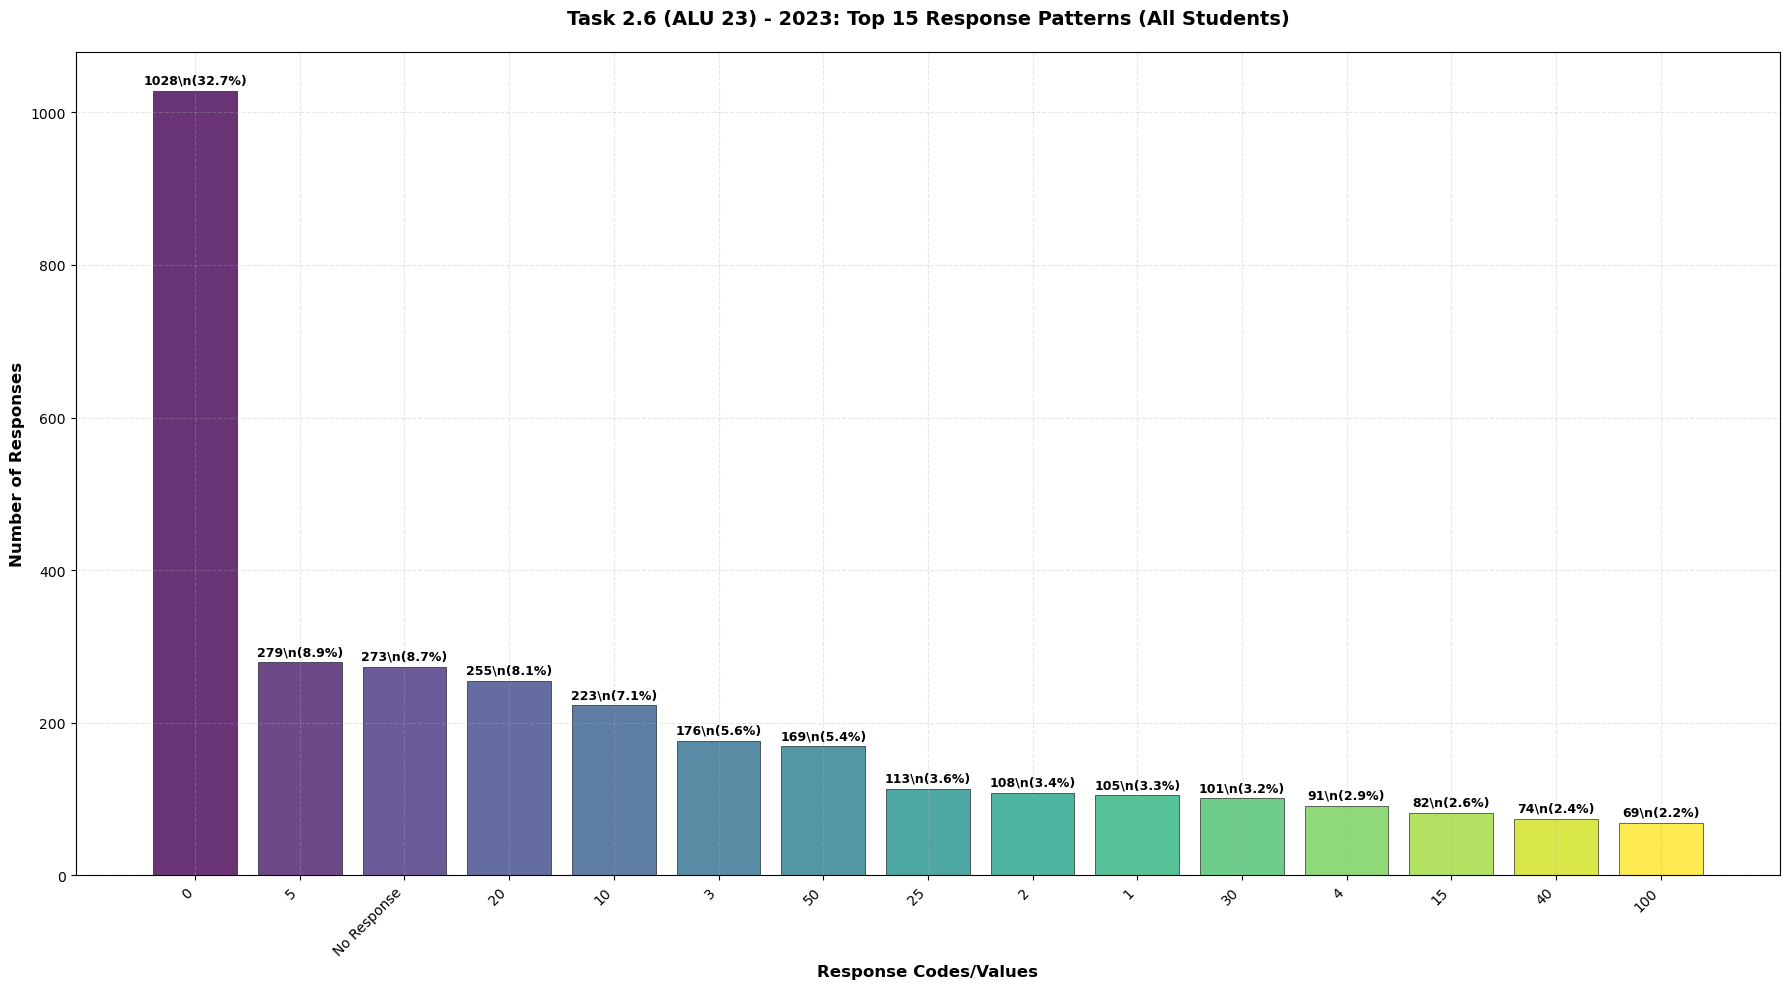

2025-10-23 12:42:07,130 - INFO - Creating gender-specific comparison visualization...


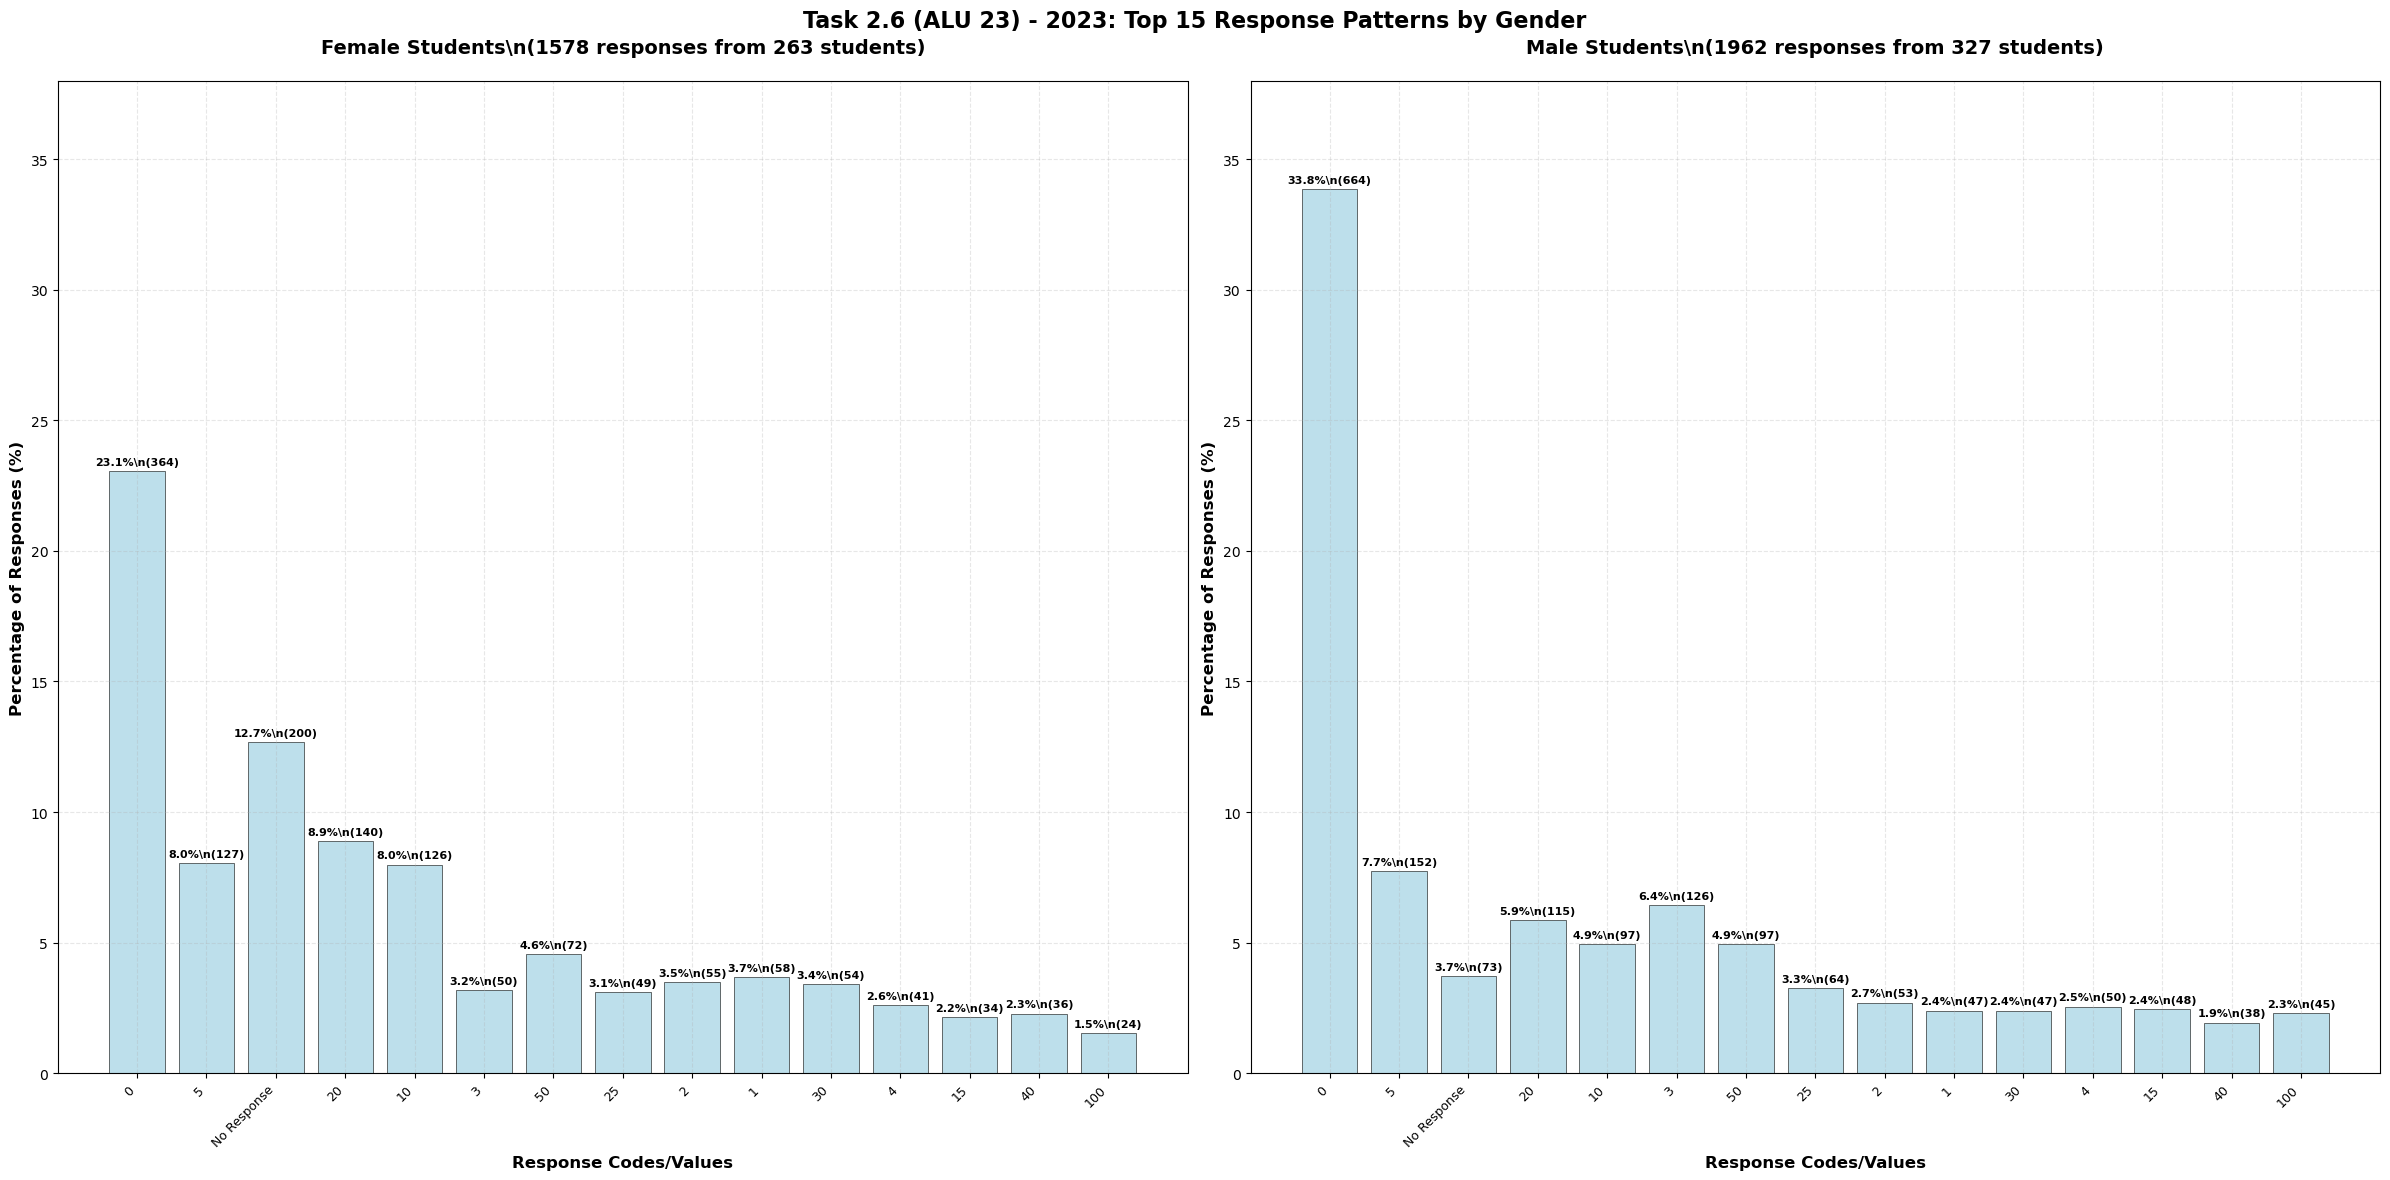

2025-10-23 12:42:07,632 - INFO - Creating grade-specific response heatmap...


\n================================================================================
DETAILED GENDER-SPECIFIC ANALYSIS SUMMARY - TASK 2.6 (ALU 23) - 2023
\nFemale Students:
  Total responses: 1578
  Unique students: 263
  Avg responses per student: 6.0
  Top 5 responses:
    1. 0: 364 (23.1%)
    2. 5: 127 (8.0%)
    3. No Response: 200 (12.7%)
    4. 20: 140 (8.9%)
    5. 10: 126 (8.0%)
\nMale Students:
  Total responses: 1962
  Unique students: 327
  Avg responses per student: 6.0
  Top 5 responses:
    1. 0: 664 (33.8%)
    2. 5: 152 (7.7%)
    3. No Response: 73 (3.7%)
    4. 20: 115 (5.9%)
    5. 10: 97 (4.9%)


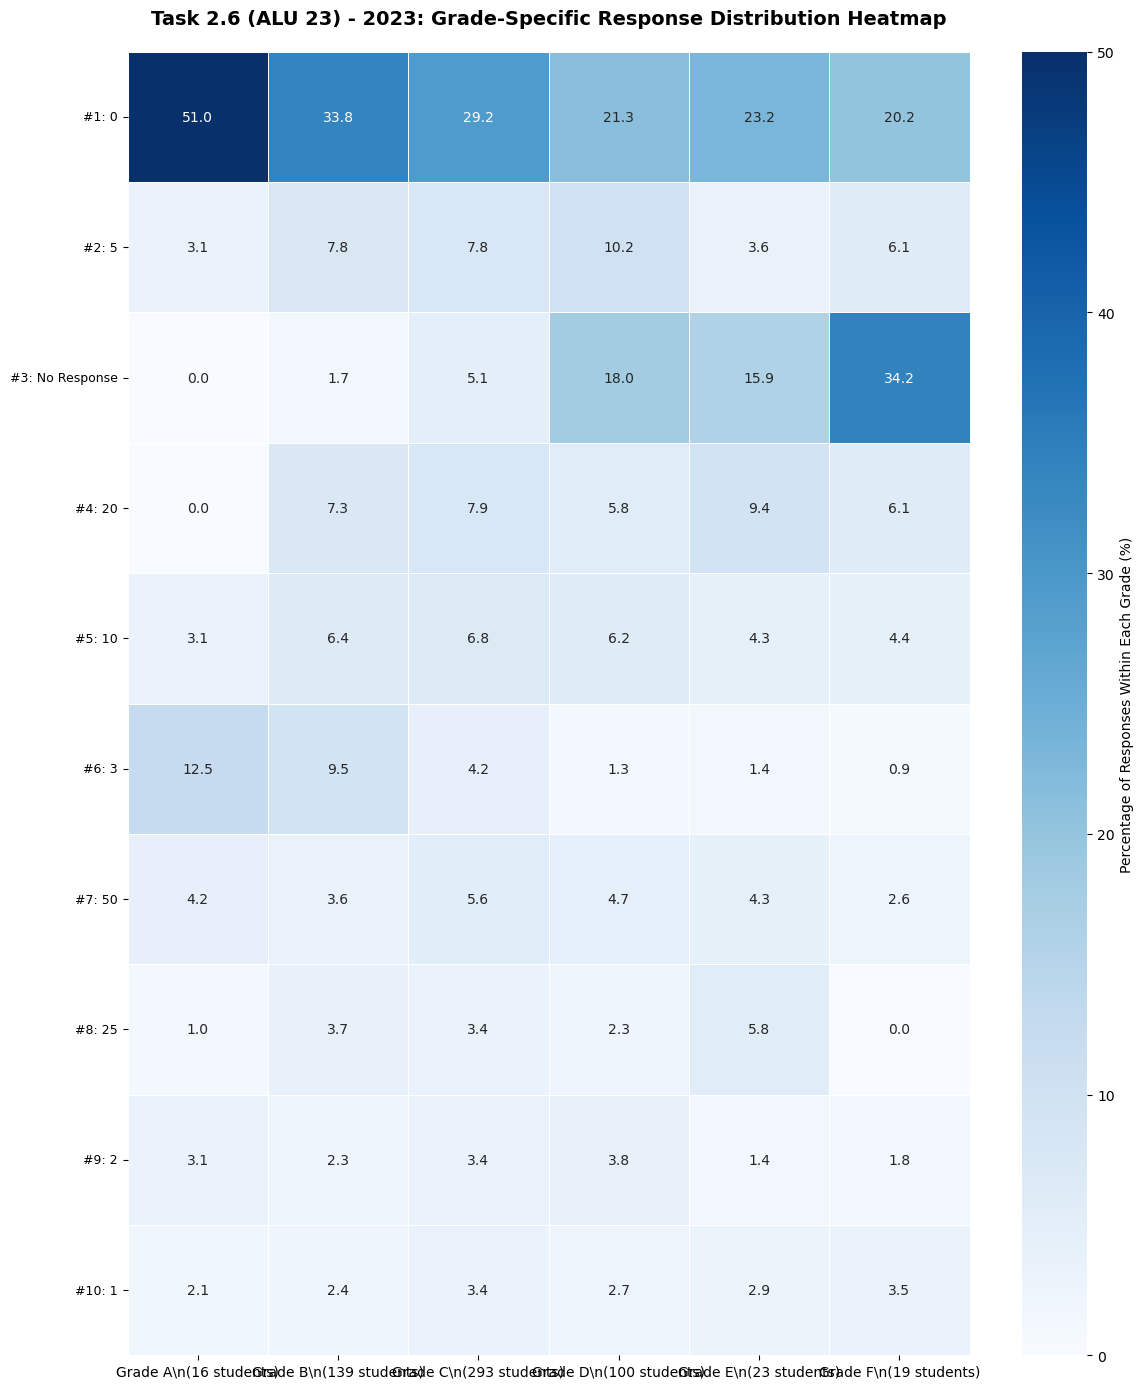

\n================================================================================
FINAL ANALYSIS SUMMARY - TASK 2.6 (ALU 23) - 2023
Total students who attempted Task 2.6: 590
Total responses recorded: 3540
Most common response: 0 (1028 times)
Unique response patterns: 61
Female students: 263 students, 1578 responses
Male students: 327 students, 1962 responses


In [10]:
# ============================================================================
# EXECUTE COMPLETE ANALYSIS - TASK 2.6 (ALU 23) - 2023
# ============================================================================

# 1. Analyze response patterns by gender
logger.info("Performing gender-based analysis...")
gender_analysis = analyzer.analyze_by_gender(task_data_clean, top_responses)

# 2. Get student performance data for additional analysis
student_data = analyzer.get_student_performance_data(df)

# 3. Create overall response distribution visualization
logger.info("Creating overall response distribution visualization...")
visualizer.plot_overall_response_distribution(top_responses, top_n=15)

# 4. Create gender-specific comparison visualization
logger.info("Creating gender-specific comparison visualization...")
visualizer.plot_gender_response_comparison(gender_analysis, top_responses, top_n=15)

# 5. Create grade-specific heatmap
logger.info("Creating grade-specific response heatmap...")
visualizer.plot_grade_response_heatmap(task_data_clean, student_data, top_n=10)

# Print final summary
print("\\n" + "="*80)
print("FINAL ANALYSIS SUMMARY - TASK 2.6 (ALU 23) - 2023")
print("="*80)
print(f"Total students who attempted Task 2.6: {task_data_clean['student_id'].nunique()}")
print(f"Total responses recorded: {len(task_data_clean)}")
print(f"Most common response: {top_responses.index[0]} ({top_responses.iloc[0]} times)")
print(f"Unique response patterns: {len(task_data_clean['response_clean'].value_counts())}")

# Gender breakdown
for gender in ['F', 'M']:
    gender_name = 'Female' if gender == 'F' else 'Male'
    data = gender_analysis[gender]
    print(f"{gender_name} students: {data['unique_students']} students, {data['total_responses']} responses")

print("="*80)